# 一维

## 根据输入构建dp

<span id='P.70'></span>
### [70. 爬楼梯](https://leetcode.cn/problems/climbing-stairs/)
$\iff$ <span id='LCR.127'></span> [LCR 127. 跳跃训练](https://leetcode.cn/problems/qing-wa-tiao-tai-jie-wen-ti-lcof/)<br>
假设你正在爬楼梯。需要`n`阶你才能到达楼顶。<br>
每次你可以爬`1`或`2`个台阶。你有多少种不同的方法可以爬到楼顶呢？

In [ ]:
n = 3

dp = [0 for _ in range(n + 1)]
dp[0] = 1
for ii in range(1, n + 1):
    dp[ii] = dp[ii - 1] + dp[ii - 2]

print(dp[-1])

<span id='P.746'></span>
#### [746. 使用最小花费爬楼梯](https://leetcode.cn/problems/min-cost-climbing-stairs/description/)
给你一个整数数组`cost`，其中`cost[i]`是从楼梯第`i`个台阶向上爬需要支付的费用。一旦你支付此费用，即可选择向上爬一个或者两个台阶。<br>
你可以选择从下标为`0`或下标为`1`的台阶开始爬楼梯。<br>
请你计算并返回达到楼梯顶部的最低花费。

In [ ]:
cost = [10, 15, 20]
cost = [1, 100, 1, 1, 1, 100, 1, 1, 100, 1]

dp = [0 for _ in range(len(cost) + 1)]
for ii in range(2, len(cost) + 1):
    dp[ii] = min(dp[ii - 1] + cost[ii - 1], dp[ii - 2] + cost[ii - 2])

print(dp[-1])

<span id='P.53'></span>
### [53. 最大子数组和](https://leetcode.cn/problems/maximum-subarray/)
$\iff$ <span id='LCR.161'></span> [LCR 161. 连续天数的最高销售额](https://leetcode.cn/problems/lian-xu-zi-shu-zu-de-zui-da-he-lcof/)  
给你一个整数数组`nums`，请你找出一个具有最大和的连续子数组（子数组最少包含一个元素），返回其最大和。<br>
**子数组**是数组中的一个连续部分。

> **题解**:<br>
$dp(i)$代表以第$i$个数结尾的「连续子数组的最大和」<br>
转移方程: $dp(i)=max(dp(i−1)+nums[i],\ nums[i])$

In [ ]:
nums = [-2,1,-3,4,-1,2,1,-5,4]

dp = [-float("inf") for _ in range(len(nums))]
dp[0] = nums[0]
for ii in range(1, len(nums)):
    dp[ii] = max(dp[ii - 1] + nums[ii], nums[ii])

print(max(dp))

<span id='P.32'></span>
#### [32. 最长有效括号](https://leetcode.cn/problems/longest-valid-parentheses/)
给你一个只包含`'('`和`')'`的字符串，找出最长有效（格式正确且连续）括号子串的长度。

> **题解**:<br>
$\textit{dp}[i]$表示以下标$i$字符结尾的最长有效括号的长度<br>
从前往后遍历字符串求解 $\textit{dp}$ 值，我们每两个字符检查一次：

1. $s[i] = \text{')'}$且$s[i - 1] = \text{‘(’}$, 也就是字符串形如`"……()"`，我们可以推出:
$$\textit{dp}[i]=\textit{dp}[i-2]+2$$
2. $s[i] = \text{')'}$且$s[i - 1] = \text{')'}$, 也就是字符串形如`"……))"`, 我们可以推出:<br>
if $s[i - \textit{dp}[i - 1] - 1] = \text{'('}$, then
$$\textit{dp}[i]=\textit{dp}[i-1] + 2 + \textit{dp}[i-\textit{dp}[i-1]-2]$$
期字符及索引的对应关系如下: 
$$\begin{matrix}
\cdots & ) & ( & ( & \cdots & ) & ) \\
\cdots & i-\textit{dp}[i-1]-2, & i-\textit{dp}[i-1]-1, & i-\textit{dp}[i-1], & \cdots & i - 1, & i
\end{matrix}$$

In [ ]:
s = ")(((((()())()()))()(()))("

if len(s) > 1:
    dp = [0 for _ in range(len(s))]
    if s[0 : 2] == "()":
        dp[1] = 2
    for ii in range(1, len(s)):
        if s[ii] == ')' and s[ii - 1] == '(':
            if ii - 2 >= 0:
                dp[ii] = dp[ii - 2] + 2
            else:
                dp[ii] = 2
        elif s[ii] == ')' and s[ii - 1] == ')':
            if ii - dp[ii - 1] - 1 >= 0 and s[ii - dp[ii - 1] - 1] == '(':
                if ii - dp[ii - 1] - 2 >= 0:
                    dp[ii] = dp[ii - 1] + 2 + dp[ii - dp[ii - 1] - 2]
                else:
                    dp[ii] = dp[ii - 1] + 2
    print(max(dp))
else:
    print(0)

<span id='P.198'></span>
### [198. 打家劫舍](https://leetcode.cn/problems/house-robber/)
$\iff$ <span id='LCR.089'></span>[LCR 089. 打家劫舍](https://leetcode.cn/problems/Gu0c2T)<br>
你是一个专业的小偷，计划偷窃沿街的房屋。每间房内都藏有一定的现金，影响你偷窃的唯一制约因素就是相邻的房屋装有相互连通的防盗系统，**如果两间相邻的房屋在同一晚上被小偷闯入，系统会自动报警**。<br>
给定一个代表每个房屋存放金额的非负整数数组，计算你**不触动警报装置的情况下**，一夜之内能够偷窃到的最高金额。

>题解:  
用$dp[i]$表示前$i$间房屋能偷窃到的最高总金额,  
状态转移方程:$$dp[i]=max(dp[i−2]+nums[i],dp[i−1])$$  
边界条件为:  
$$ \begin{cases} \begin{array}{l,l}
dp[0]=nums[0], & 只有一间房屋，则偷窃该房屋 \\
dp[1]=max(nums[0],nums[1]), & 只有两间房屋，选择其中金额较高的房屋进行偷窃 \\
\end{array} \end{cases} $$

In [ ]:
nums = [1,2,3,1]

dp = [0 for ii in range(len(nums))]
dp[0] = nums[0]
if len(nums) > 1:
    dp[1] = max(nums[0], nums[1])
    for ii in range(2, len(nums)):
        dp[ii] = max(dp[ii - 2] + nums[ii], dp[ii - 1])

print(dp[-1])

<span id='P.198'></span>
#### [213. 打家劫舍 II](https://leetcode.cn/problems/house-robber-ii/)
$\iff$ <span id='LCR.090'></span>[LCR 090. 打家劫舍 II](https://leetcode.cn/problems/PzWKhm)<br>
你是一个专业的小偷，计划偷窃沿街的房屋，每间房内都藏有一定的现金。这个地方所有的房屋都**围成一圈**，这意味着第一个房屋和最后一个房屋是紧挨着的。同时，相邻的房屋装有相互连通的防盗系统，**如果两间相邻的房屋在同一晚上被小偷闯入，系统会自动报警**。

给定一个代表每个房屋存放金额的非负整数数组，计算你**在不触动警报装置的情况下**，今晚能够偷窃到的最高金额。
> 思路:<br>
如何才能保证第一间房屋和最后一间房屋不同时偷窃呢？<br>
如果偷窃了第一间房屋，则不能偷窃最后一间房屋，因此偷窃房屋的范围是第一间房屋到最后第二间房屋；<br>
如果偷窃了最后一间房屋，则不能偷窃第一间房屋，因此偷窃房屋的范围是第二间房屋到最后一间房屋。<br><br>
假设数组$nums$的长度为$n$。<br>
如果不偷窃最后一间房屋，则偷窃房屋的下标范围是$[0,n−2]$；<br>
如果不偷窃第一间房屋，则偷窃房屋的下标范围是$[1,n−1]$。<br>
在确定偷窃房屋的下标范围之后，即可用第 [198](#P.198) 题的方法解决。

In [ ]:
nums = [1,1,9,1,1,7,1]
# nums = [200,3,140,20,10]


def rob(nums):
    dp = [0 for ii in range(len(nums))]
    dp[0] = nums[0]
    dp[1] = max(nums[0], nums[1])
    for ii in range(2, len(nums)):
        dp[ii] = max(dp[ii - 2] + nums[ii], dp[ii - 1])
    return dp[-1]

if len(nums) > 3:
    print(max(rob(nums[0:-1]), rob(nums[1:])))
else:
    print(max(nums))

<span id='P.91'></span>
### [91. 解码方法](https://leetcode.cn/problems/decode-ways/)
一条包含字母`A-Z`的消息通过以下映射进行了**编码**：

>'A' -> "1"<br>
'B' -> "2"<br>
...<br>
'Z' -> "26"

要**解码**已编码的消息，所有数字必须基于上述映射的方法，反向映射回字母（可能有多种方法）。例如，`"11106"`可以映射为：

- `"AAJF"`，将消息分组为`(1 1 10 6)`
-`"KJF"`，将消息分组为`(11 10 6)`

注意，消息不能分组为`(1 11 06)`，因为`"06"`不能映射为`"F"`，这是由于`"6"`和`"06"`在映射中并不等价。<br>
给你一个只含数字的**非空**字符串`s`，请计算并返回**解码**方法的**总数**。

In [ ]:
s = "06"

dp = [0 for _ in range(len(s))]
if s[0] != '0':
    dp[0] = 1
if len(s) > 1:
    if s[1] != '0':
        dp[1] += dp[0]
    if s[0] != '0' and int(s[0:2]) < 27:
        dp[1] += 1
    for ii in range(2, len(s)):
        if s[ii] != '0':
            dp[ii] += dp[ii-1]
        if s[ii - 1] != '0' and int(s[ii - 1 : ii + 1]) < 27:
            dp[ii] += dp[ii-2]
print(dp[-1])

<span id='LCR.165'></span>
#### [LCR 165. 解密数字](https://leetcode.cn/problems/ba-shu-zi-fan-yi-cheng-zi-fu-chuan-lcof/)
现有一串神秘的密文`ciphertext`，经调查，密文的特点和规则如下：<br>
密文由非负整数组成<br>
数字 0-25 分别对应字母 a-z<br>
请根据上述规则将密文`ciphertext`解密为字母，并返回共有多少种解密结果。

**示例 1**:
>**输入**: ciphertext = 216612<br>
**输出**: `6`<br>
**解释**: 216612 解密后有 6 种不同的形式，分别是 "cbggbc"，"vggbc"，"vggm"，"cbggm"，"cqggbc" 和 "cqggm" 

In [ ]:
ciphertext = 216612

num_str = str(ciphertext)
dp = [0 for _ in range(len(num_str))]
dp[0] = 1
if len(num_str) > 1:
    dp[1] = 1
    if num_str[0] != '0' and int(num_str[0:2]) < 26:
        dp[1] += 1
    for ii in range(2, len(num_str)):
        dp[ii] += dp[ii-1]
        if num_str[ii - 1] != '0' and int(num_str[ii - 1 : ii + 1]) < 26:
            dp[ii] += dp[ii-2]

print(dp[-1])

<span id='P.42'></span>
### [42. 接雨水](https://leetcode.cn/problems/trapping-rain-water/)
给定`n`个非负整数表示每个宽度为`1`的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。

**示例 1**：
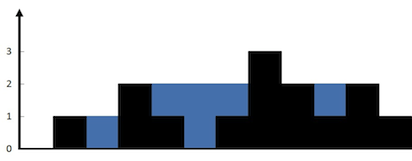
> **输入**：height = [0,1,0,2,1,0,1,3,2,1,2,1]<br>
**输出**：6<br>
**解释**：上面是由数组 [0,1,0,2,1,0,1,3,2,1,2,1] 表示的高度图，在这种情况下，可以接 6 个单位的雨水（蓝色部分表示雨水）。 

> **题解**: 
> 1. 左上绿色面积 + 右上红色面积 - 下图矩形面积 - sum(height)
> 2. min(绿色, 红色) - height
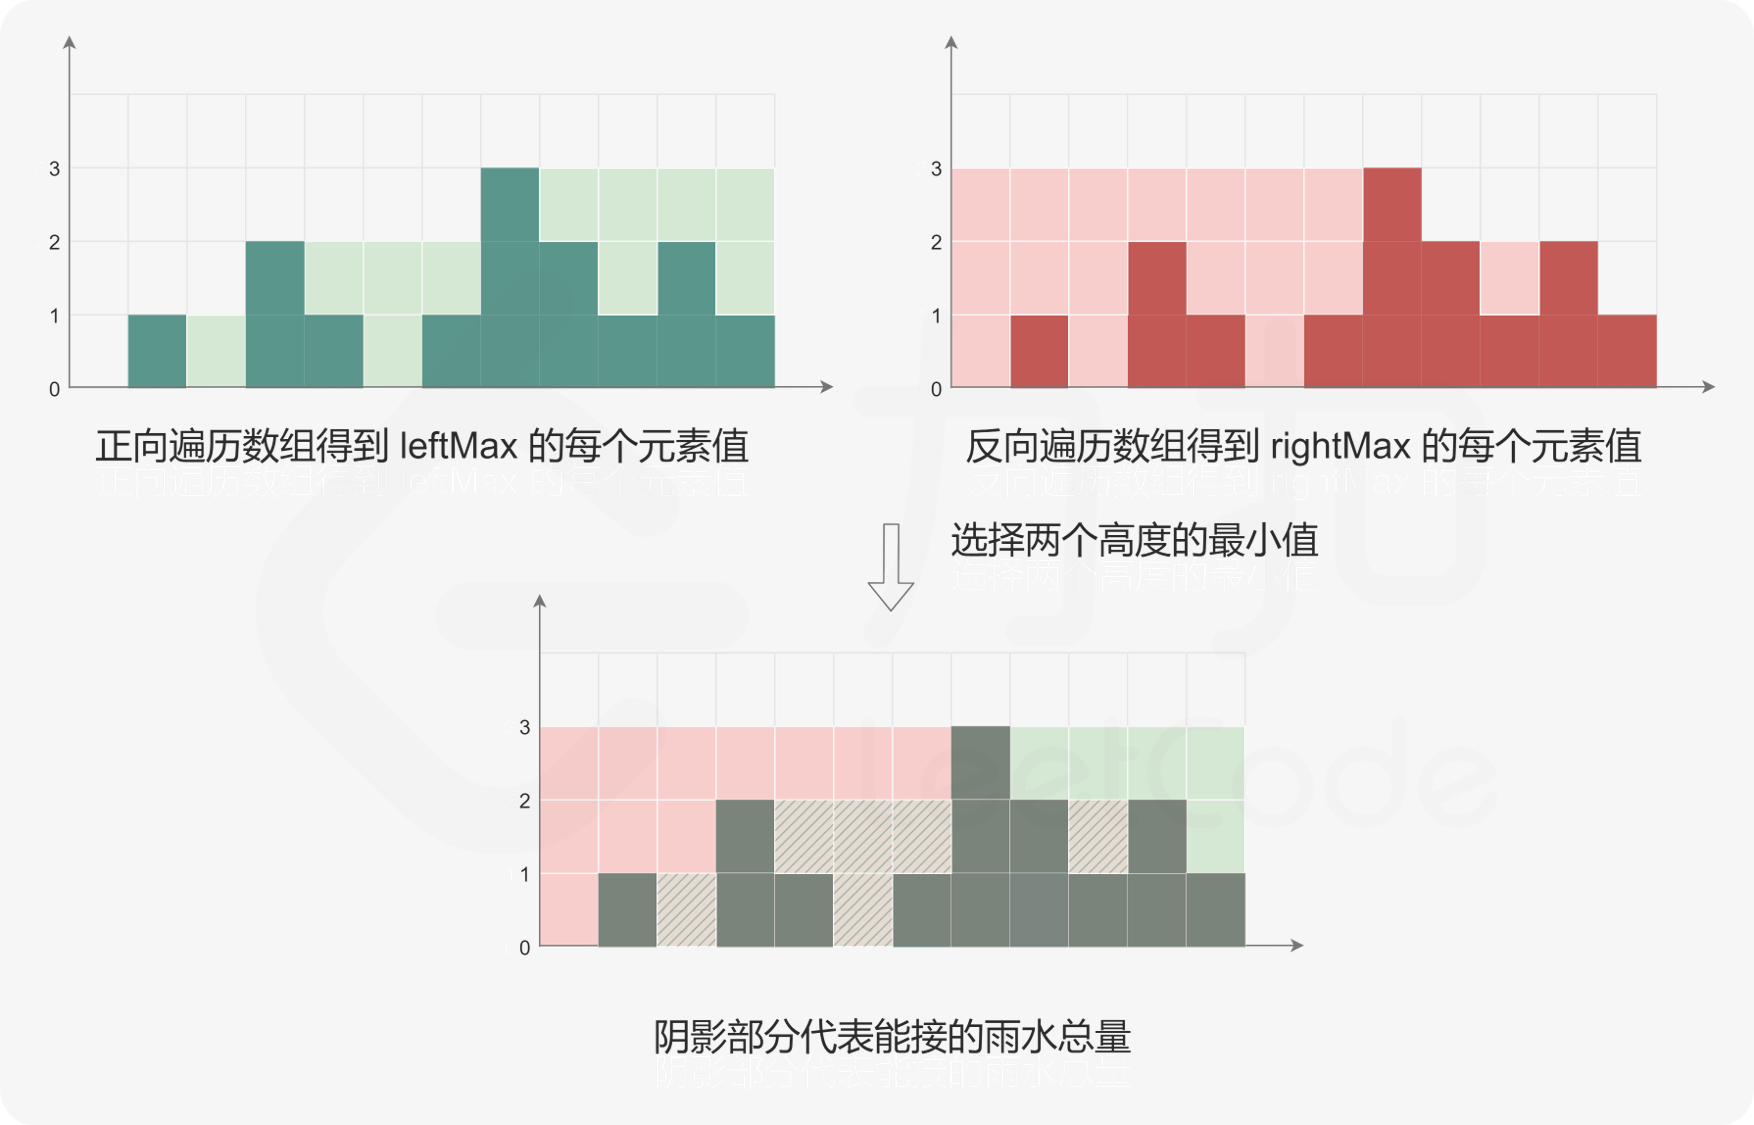

In [ ]:
height = [0,1,0,2,1,0,1,3,2,1,2,1]

up = [num for num in height]
down = [num for num in height]
for ii in range(1, len(height)):
    up[ii] = max(up[ii - 1], height[ii])
for ii in range(len(height) - 2, -1, -1):
    down[ii] = max(down[ii + 1], height[ii])

count = 0
for ii in range(len(height)):
    count += up[ii] + down[ii] - down[0] - height[ii]
    # count += min(up[ii], down[ii]) - height[ii]
    
print(count)

### todo: [639. 解码方法 II](https://leetcode-cn.com/problems/decode-ways-ii/)

dp[i] 由 dp[i-1] 和 dp[i-2]) 推得
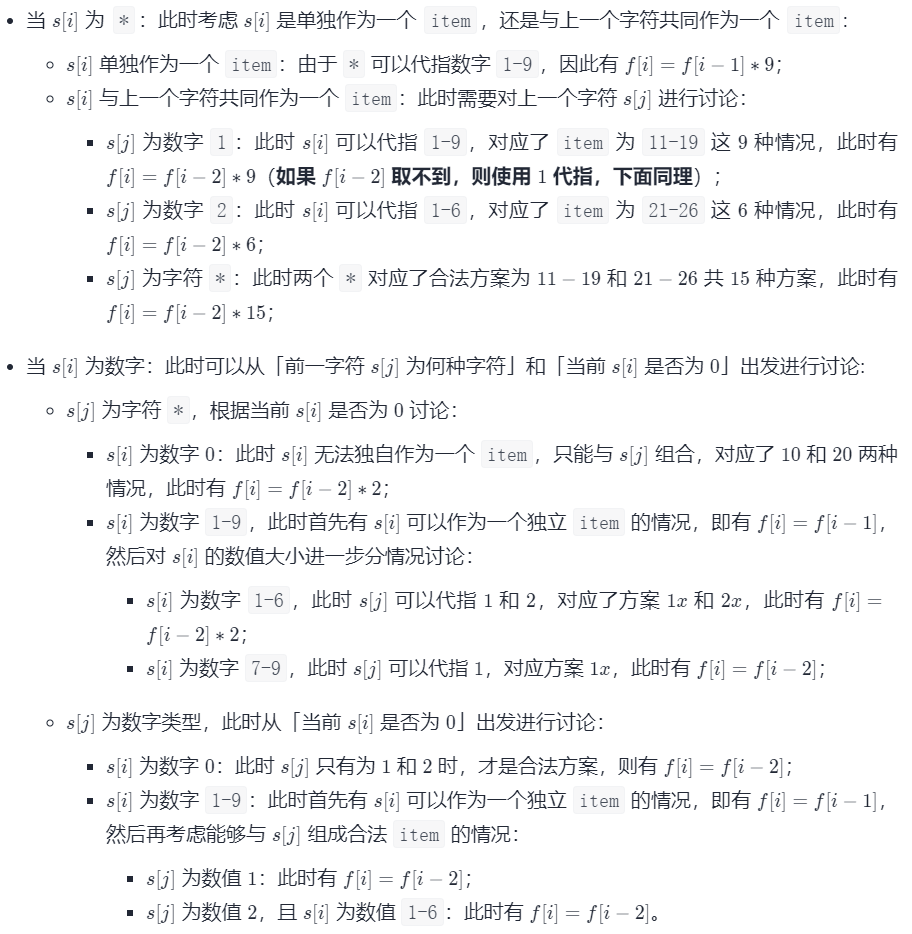

In [ ]:
s = "*10*1"

dp = [0 for _ in range(len(s))]
if s[0] == '*':
    dp[0] = 9
elif s[0] in set([str(ii) for ii in range(1,10)]):
    dp[0] = 1

for ii in range(1,len(s)):
    if s[ii] == '*':
        dp[ii] += dp[ii-1]*9
        if s[ii-1] == '1':
            if ii-2 >= 0:
                dp[ii] += dp[ii-2]*9
            else:
                dp[ii] += 9
        elif s[ii-1] == '2':
            if ii-2 >= 0:
                dp[ii] += dp[ii-2]*6
            else:
                dp[ii] += 6
        elif s[ii-1] == '*':
            if ii-2 >= 0:
                dp[ii] += dp[ii-2]*15
            else:
                dp[ii] += 15
    else:
        if s[ii-1] == '*':
            if s[ii] == '0':
                if ii-2 >= 0:
                    dp[ii] += dp[ii-2]*2
                else:
                    dp[ii] += 2
            else: #1-9
                dp[ii] += dp[ii-1]
                if s[ii] in set(['1','2','3','4','5','6']):
                    if ii-2 >= 0: 
                        dp[ii] += dp[ii-2]*2
                    else:
                        dp[ii] += 2
                elif s[ii] in set(['7','8','9']):
                    if ii-2 >= 0: 
                        dp[ii] += dp[ii-2]
                    else:
                        dp[ii] += 1
        else:
            if s[ii] == '0':
                if s[ii-1] in set(['1','2']):
                    if ii-2 >= 0: 
                        dp[ii] += dp[ii-2]
                    else:
                        dp[ii] += 1
            else: #1-9
                dp[ii] += dp[ii-1]
                if s[ii-1] == '1':
                    if ii-2 >= 0: 
                        dp[ii] += dp[ii-2]
                    else:
                        dp[ii] += 1
                elif s[ii-1] == '2' and s[ii] in set(['1','2','3','4','5','6']):
                    if ii-2 >= 0: 
                        dp[ii] += dp[ii-2]
                    else:
                        dp[ii] += 1
        
print(dp)
print( dp[-1]%(10**9+7) )

In [ ]:
#include <iostream>
#include <vector>
#include <unordered_set>
#include <string>
using namespace std;

string s = "*10*1";

unordered_set<char> set19 = {'1','2','3','4','5','6','7','8','9'};
unordered_set<char> set16 = {'1','2','3','4','5','6'};
vector<long long> dp;
for (int ii=0;ii<s.size();ii++){
    dp.emplace_back(0);
}
if (s[0] == '*'){
    dp[0] = 9;
}
else if (set19.count(s[0]) == 1){
    dp[0] = 1;
}

for (int ii=1;ii<s.size();ii++){
    if (s[ii] == '*'){
        dp[ii] += (dp[ii-1]*9)%1000000007;
        if (s[ii-1] == '1'){
            if (ii-2 >= 0){
                dp[ii] += (dp[ii-2]*9)%1000000007;
            }
            else {
                dp[ii] += 9;
            }
        }
        else if (s[ii-1] == '2') {
            if (ii-2 >= 0) {
                dp[ii] += (dp[ii-2]*6)%1000000007;
            }
            else {
                dp[ii] += 6;
            }
        }
        else if (s[ii-1] == '*'){
            if (ii-2 >= 0){
                dp[ii] += (dp[ii-2]*15)%1000000007;
            }
            else {
                dp[ii] += 15;
            }
        }
    }
    else {
        if (s[ii-1] == '*'){
            if (s[ii] == '0'){
                if (ii-2 >= 0) {
                    dp[ii] += (dp[ii-2]*2)%1000000007;
                }
                else {
                    dp[ii] += 2;
                }
            }
            else{
                dp[ii] += (dp[ii-1])%1000000007;
                if (set16.count(s[ii]) == 1) {
                    if (ii-2 >= 0) {
                        dp[ii] += (dp[ii-2]*2)%1000000007;
                    } 
                    else {
                        dp[ii] += 2;
                    }
                }
                else if (s[ii] == '7' || s[ii] == '8' || s[ii] == '9') {
                    if (ii-2 >= 0){
                        dp[ii] += (dp[ii-2])%1000000007;
                    } 
                    else {
                        dp[ii] += 1;
                    }
                }
            }
        }
        else {
            if (s[ii] == '0') {
                if (s[ii-1] == '1' || s[ii-1] == '2') {
                    if (ii-2 >= 0){
                        dp[ii] += (dp[ii-2])%1000000007;
                    } 
                    else {
                        dp[ii] += 1;
                    }
                }
            }
            else {
                dp[ii] += (dp[ii-1])%1000000007;
                if (s[ii-1] == '1') {
                    if (ii-2 >= 0) {
                        dp[ii] += (dp[ii-2])%1000000007;
                    }
                    else {
                        dp[ii] += 1;
                    }
                }

                else if (s[ii-1] == '2' && set16.count(s[ii]) == 1) {
                    if (ii-2 >= 0) {
                        dp[ii] += (dp[ii-2])%1000000007;
                    }
                    else {
                        dp[ii] += 1;
                    }
                }
            }
        }
    }
}
cout << dp.back()%1000000007 << endl;

# 根据目标值 target, 构建 target + 1个元素的dp数组

## 一维

<span id='P.322'></span>
### [322. 零钱兑换](https://leetcode.cn/problems/coin-change/)
$\iff$ <span id='LCR.103'></span>[LCR 103. 零钱兑换](https://leetcode.cn/problems/gaM7Ch)<br>
给你一个整数数组`coins`，表示不同面额的硬币；以及一个整数`amount`，表示总金额。<br>
计算并返回可以凑成总金额所需的**最少的硬币个数**。如果没有任何一种硬币组合能组成总金额，返回`-1`。<br>
你可以认为每种硬币的数量是无限的。

In [ ]:
coins = [1, 2, 5]
amount = 11

dp = [float("inf") for _ in range(amount + 1)]
dp[0] = 0
for ii in range(1, amount + 1):
    for coin in coins:
        if ii - coin >= 0:
            dp[ii] = min(dp[ii], dp[ii - coin] + 1)
if dp[-1] == float("inf"):
    print(-1)
else:
    print(dp[-1])

<span id='P.377'></span>
#### [377. 组合总和 Ⅳ](https://leetcode.cn/problems/combination-sum-iv/)
$\iff$ <span id='LCR.104'></span> [LCR 104. 组合总和 Ⅳ](https://leetcode.cn/problems/D0F0SV/)<br>
给你一个由**不同**整数组成的数组`nums`，和一个目标整数`target`。请你从`nums`中找出并返回总和为`target`的元素组合的个数。

**示例 1**:  

**输入**: $nums = [1,2,3], target = 4$  
**输出**: 7  
**解释**:   
所有可能的组合为:  
(1, 1, 1, 1)  
(1, 1, 2)  
(1, 2, 1)  
(1, 3)  
(2, 1, 1)  
(2, 2)  
(3, 1)  
请注意，顺序不同的序列被视作不同的组合。  


>题解:  
$dp[x]$表示选取的元素之和等于$x$的方案数  
1. 初始化$dp[0]=1$;(只有当不选取任何元素时，元素之和才为$0$，因此只有$1$种方案 )
2. 遍历$i$从$1$到$target$，对于每个$i$，进行如下操作:
    1. 遍历数组$nums$中的每个元素$num$，当$num≤i$时，将$dp[i−num]$的值加到$dp[i]$。
3. 最终得到$dp[target]$的值即为答案。


In [ ]:
# nums = [1,2,3]
# target = 4
nums = [4,2,1]
target = 32

dp = [0 for _ in range(target + 1)]
dp[0] = 1
for ii in range(1, target + 1): # 先遍历目标
    for num in nums:            # 再遍历元素
        if ii >= num:
            dp[ii] += dp[ii - num]
print(dp[-1])

<span id='P.139'></span>
#### [139. 单词拆分](https://leetcode.cn/problems/word-break/description/)
给你一个字符串`s`和一个字符串列表`wordDict`作为字典。如果可以利用字典中出现的一个或多个单词拼接出`s`则返回`true`。<br>
**注意**：不要求字典中出现的单词全部都使用，并且字典中的单词可以重复使用。

In [ ]:
s = "leetcode"
wordDict = ["leet", "code"]

dp = [False for _ in range(len(s) + 1)]
dp[0] = True
for ii in range(1, len(s) + 1):
    for word in wordDict:
        if ii - len(word) >= 0:
            dp[ii] = (dp[ii - len(word)] and s[ii - len(word) : ii] == word) or dp[ii]

print(dp[-1]) 

<span id='P.279'></span>
#### [279. 完全平方数](https://leetcode.cn/problems/perfect-squares)
给你一个整数`n`，返回*和为`n`的完全平方数的最少数量*。<br>
**完全平方数**是一个整数，其值等于另一个整数的平方；换句话说，其值等于一个整数自乘的积。例如，`1`、`4`、`9`和`16`都是完全平方数，而`3`和`11`不是。

示例 1：
> **输入**：n = `12`<br>
> **输出**：3<br>
> **解释**：`12 = 4 + 4 + 4`

示例 2：
> **输入**：n = `13`<br>
> **输出**：2<br>
> **解释**：`13 = 4 + 9`

In [ ]:
n = 13

dp = [float("inf") for _ in range(n + 1)]
dp[0] = 0
for ii in range(1, n + 1):
    for jj in range(1, int(n**0.5) + 1):
        if ii - jj**2 >= 0:
            dp[ii] = min(dp[ii], dp[ii - jj**2] + 1)

print(dp[-1])

<span id='P.518'></span>
### [518. 零钱兑换 II](https://leetcode.cn/problems/coin-change-ii/)  
给你一个整数数组`coins`表示不同面额的硬币，另给一个整数`amount`表示总金额。<br>
请你计算并返回可以凑成总金额的硬币组合数。如果任何硬币组合都无法凑出总金额，返回`0`。<br>
假设每一种面额的硬币有无限个。 

> 与[377. 组合总和 Ⅳ](#P.377)的区别:<br>本题是无序的, 377是有序的, 两者的循环顺序不同

In [ ]:
coins = [4,2,1]
amount = 32

dp = [0 for _ in range(amount + 1)]
dp[0] = 1
for coin in coins:                     # 先遍历元素
    for ii in range(coin, amount + 1): # 再遍历目标
        dp[ii] += dp[ii - coin]

print(dp[-1])

### todo 740. 删除并获得点数

In [ ]:
# nums = [2,2,3,3,3,4]
# nums = [2,2,3,3,3,4,4]
# nums = [2,2,3,4,4,5,6,7,7,7,8,8,9]

# # 思路：动态规划，同198. 打家劫舍
# list1 = []
# dict1 = {}
# for ii in range(len(nums)):
#     if nums[ii] not in dict1:
#         list1.append(nums[ii])
#         dict1[nums[ii]] = 1
#     else:
#         dict1[nums[ii]] += 1
# list1.sort()
# dp = [0 for _ in range(len(list1))]
# dp[0] = list1[0]*dict1[list1[0]]
# if len(list1) > 1:
#     if list1[1] == list1[0] + 1:
#         dp[1] = max(list1[0]*dict1[list1[0]], list1[1]*dict1[list1[1]])
#     else:
#         dp[1] = list1[0]*dict1[list1[0]]+list1[1]*dict1[list1[1]]
# if len(list1) > 2:
#     for ii in range(2,len(list1)):
#         if list1[ii] == list1[ii-1] + 1:
#             dp[ii] = max(dp[ii-2] + list1[ii]*dict1[list1[ii]], dp[ii-1])
#         else:
#             dp[ii] = dp[ii-1] + list1[ii]*dict1[list1[ii]]
# print(dp[-1])

# 背包问题/Knapsack problem
给定一组物品，每种物品都有自己的重量weights和价格values，在限定的总重量Volume内，如何选择才能使得物品的总价格最高。
todo
- [ ] https://zhuanlan.zhihu.com/p/93857890
- [ ] https://github.com/tianyicui/pack/blob/master/V2.pdf
- [ ] https://leetcode.cn/problems/coin-change-ii/solutions/821592/gong-shui-san-xie-xiang-jie-wan-quan-bei-6hxv/

## 归纳

In [45]:
weights = [2,2,6,5,4]
values = [3,6,5,4,6]
Volume = 9
# weights = [2,2,3,1,5,2]
# values = [2,3,1,5,4,3]
# Volume = 10
# weights = [8,10,6,3,7,2]
# values = [4,6,2,2,5,1]
# Volume = 12

### 最大装包价值的0-1背包问题
dp[i][j] 表示前i件物品在重量不超过j的前提下不重复装包的最大价格

In [46]:
# 不超过容量的0-1背包问题
dp = [[0] * (Volume + 1) for _ in range(len(weights) + 1)]

# # 恰好装满的0-1背包问题
# dp = [[-float('inf')] * (Volume + 1) for _ in range(len(weights) + 1)]
# for i in range(len(weights) + 1):
#     dp[i][0] = 0

for i in range(1, len(weights) + 1):
    for j in range(1, Volume + 1):
        if j >= weights[i-1]:
            dp[i][j] = max(dp[i - 1][j],                                  # 第i件物品没装入背包的情况
                           dp[i - 1][j - weights[i - 1]] + values[i - 1]) # 第i件物品装入背包的情况
        else:
            dp[i][j] = dp[i - 1][j]

for index in range(len(dp)):
    print(index, ":", dp[index])

0 : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1 : [0, 0, 3, 3, 3, 3, 3, 3, 3, 3]
2 : [0, 0, 6, 6, 9, 9, 9, 9, 9, 9]
3 : [0, 0, 6, 6, 9, 9, 9, 9, 11, 11]
4 : [0, 0, 6, 6, 9, 9, 9, 10, 11, 13]
5 : [0, 0, 6, 6, 9, 9, 12, 12, 15, 15]


### 最大装包价值的完全背包问题
dp[i][j] 表示前i件物品在重量不超过j的前提下可重复装包的最大价格

In [47]:
# 不超过容量的0-1背包问题
dp = [[0] * (Volume + 1) for _ in range(len(weights) + 1)]

# # 恰好装满的0-1背包问题
# dp = [[-float('inf')] * (Volume + 1) for _ in range(len(weights) + 1)]
# for i in range(len(weights) + 1):
#     dp[i][0] = 0

for i in range(1, len(weights) + 1):
    for j in range(Volume + 1):
        dp[i][j] = dp[i - 1][j]                                                       # 第i件物品没装入背包的情况
        if j >= weights[i - 1]:
            for k in range(1, j // weights[i - 1] + 1):
                dp[i][j] = max(dp[i][j],
                               dp[i - 1][j - weights[i - 1] * k] + values[i - 1] * k) # 第i件物品装入背包k件的情况

for index in range(len(dp)):
    print(index, ":", dp[index])

0 : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1 : [0, 0, 3, 3, 6, 6, 9, 9, 12, 12]
2 : [0, 0, 6, 6, 12, 12, 18, 18, 24, 24]
3 : [0, 0, 6, 6, 12, 12, 18, 18, 24, 24]
4 : [0, 0, 6, 6, 12, 12, 18, 18, 24, 24]
5 : [0, 0, 6, 6, 12, 12, 18, 18, 24, 24]


### 可行装包数量的0-1背包问题
dp[i][j] 表示前i件物品在重量不超过j的前提下不重复装包的最大价格

In [48]:
dp = [[0] * (Volume + 1) for _ in range(len(weights) + 1)]
dp[0][0] = 1
for i in range(1, len(weights) + 1):
    for j in range(0, Volume + 1):                     # 注意从0开始，与求最大价值不同
        if j >= weights[i - 1]:
            dp[i][j] = (dp[i - 1][j] +                 # 第i件物品没装入背包的情况
                        dp[i - 1][j - weights[i - 1]]) # 第i件物品装入背包的情况
        else:
            dp[i][j] = dp[i - 1][j]

for index in range(len(dp)):
    print(index, ":", dp[index])
    
print('不超过容量的0-1背包问题可行方案数:', sum(dp[-1]))
print('恰好装满的0-1背包问题可行方案数:', dp[-1][-1])

# 不超过容量的01背包问题可行方案数为16，即：
# None, (2), (2), (6), (5), (4), (2,2), (2,6), (2,5), (2,4),
# (2,6), (2,5), (2,4), (5,4), (2,2,5), (2,2,4)
# 恰好装满的01背包问题可行方案数为2，即：
# (5,4), (2,2,5)

0 : [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1 : [1, 0, 1, 0, 0, 0, 0, 0, 0, 0]
2 : [1, 0, 2, 0, 1, 0, 0, 0, 0, 0]
3 : [1, 0, 2, 0, 1, 0, 1, 0, 2, 0]
4 : [1, 0, 2, 0, 1, 1, 1, 2, 2, 1]
5 : [1, 0, 2, 0, 2, 1, 3, 2, 3, 2]
不超过容量的0-1背包问题可行方案数: 16
恰好装满的0-1背包问题可行方案数: 2


### 可行装包数量的完全背包问题
dp[i][j] 表示前i件物品在重量不超过j的前提下可重复装包的最大价格

In [49]:
dp = [[0] * (Volume + 1) for _ in range(len(weights) + 1)]
dp[0][0] = 1
for i in range(1, len(weights) + 1):
    for j in range(0, Volume + 1):                            # 注意从0开始，与求最大价值不同
        dp[i][j] = dp[i - 1][j]                               # 第i件物品没装入背包的情况
        if j >= weights[i - 1]:
            for k in range(1, j // weights[i - 1] + 1):
                dp[i][j] += dp[i - 1][j - weights[i - 1] * k] # 第i件物品装入背包k件的情况

for index in range(len(dp)):
    print(index, ":", dp[index])
print('不超过容量的0-1背包问题可行方案数:', sum(dp[-1]))
print('恰好装满的0-1背包问题可行方案数:', dp[-1][-1])

0 : [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
1 : [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
2 : [1, 0, 2, 0, 3, 0, 4, 0, 5, 0]
3 : [1, 0, 2, 0, 3, 0, 5, 0, 7, 0]
4 : [1, 0, 2, 0, 3, 1, 5, 2, 7, 3]
5 : [1, 0, 2, 0, 4, 1, 7, 2, 11, 4]
不超过容量的0-1背包问题可行方案数: 32
恰好装满的0-1背包问题可行方案数: 4


<span id='P.416'></span>
## [416. 分割等和子集](https://leetcode.cn/problems/partition-equal-subset-sum/)
$\iff$ <span id='LCR.101'></span> [LCR 101. 分割等和子集](https://leetcode.cn/problems/NUPfPr/)<br>
给你一个**只包含正整数**的**非空**数组`nums`。请你判断是否可以将这个数组分割成两个子集，使得两个子集的元素和相等。

In [50]:
nums = [1,5,11,5]

if sum(nums) % 2 == 0:
    target = sum(nums) // 2
    dp = [[0] * (target + 1) for _ in range(len(nums) + 1)]
    for i in range(1, len(nums) + 1):
        for j in range(1, target + 1):
            if j >= nums[i - 1]:
                dp[i][j] = max(dp[i - 1][j], dp[i - 1][j - nums[i - 1]] + nums[i - 1])
            else:
                dp[i][j] = dp[i - 1][j]
    print( dp[-1][-1] == target )
else:
    print( False )

True


> 题解2: 
>1. 预处理
    1. 根据**数组的长度**$n$判断数组是否可以被划分。如果$n<2$，则不可能将数组分割成元素和相等的两个子集，因此直接返回false。
    2. 计算整个数组的**元素和**$\textit{sum}$。如果$\textit{sum}$是奇数，则不可能将数组分割成元素和相等的两个子集，因此直接返回false。
    3. 计算整个数组的**最大元素**$\textit{maxNum}$。如果$\textit{maxNum}>\frac{\textit{sum}}{2}$，则除了$\textit{maxNum}$以外的所有元素之和一定小于$\textit{target}$，因此不可能将数组分割成元素和相等的两个子集，直接返回false。
2. 接下来转化为: **数组的子集之和是否等于目标值**(数组元素和$\textit{sum}$的一半):
    1. 创建二维数组$\textit{dp}$，包含$n$行$\textit{target}+1$列，其中$\textit{dp}[i][j]$表示**从数组的**$[0,i]$**下标范围内选取若干个正整数（可以是0个），是否存在一种选取方案使得被选取的正整数的和等于**$j$。
    2. 边界
        1. 如果不选取任何正整数，则被选取的正整数之和等于0。因此对于所有$0 \le i < n$，都有$\textit{dp}[i][0]=\text{true}$。
        2. 当$i==0$时，只有一个正整数$\textit{nums}[0]$可以被选取，因此$\textit{dp}[0][\textit{nums}[0]]=\text{true}$。
    3. 状态转移方程
        1. 如果$j \ge \textit{nums}[i]$，则对于当前的数字$\textit{nums}[i]$，可以选取也可以不选取，两种情况只要有一个为 true，就有 $\textit{dp}[i][j]=\text{true}$。
            1. 如果不选取$\textit{nums}[i]$，则$\textit{dp}[i][j]=\textit{dp}[i-1][j]$；
            2. 如果选取$\textit{nums}[i]$，则$\textit{dp}[i][j]=\textit{dp}[i-1][j-\textit{nums}[i]]$。
        2. 如果$j < \textit{nums}[i]$，则在选取的数字的和等于$j$的情况下，无法选取当前的数字$\textit{nums}[i]$，因此有$\textit{dp}[i][j]=\textit{dp}[i-1][j]$。
        3. 归纳如下：
$$\textit{dp}[i][j]=\begin{cases} \textit{dp}[i-1][j] \text{ or } \textit{dp}[i-1][j-\textit{nums}[i]], & j \ge \textit{nums}[i] \\ \textit{dp}[i-1][j], & j < \textit{nums}[i] \end{cases}$$

In [3]:
#include <iostream>
#include <vector>
bool canPartition(std::vector<int>& nums) {
    // 1.A
    if (nums.size() < 2) {
        return false;
    }
    // 1.B
    int sum = accumulate(nums.begin(), nums.end(), 0);
    if (sum % 2 == 1) {
        return false;
    }
    // 1.C
    int maxNum = *max_element(nums.begin(), nums.end());
    int target = sum / 2;
    if (maxNum > target) {
        return false;
    }
    // 2
    std::vector<bool> row(target + 1, false);
    std::vector<std::vector<bool>> dp(nums.size(), row);
    // 2.B.a
    for (int i = 0; i < nums.size(); i++) {
        dp[i][0] = true;
    }
    // 2.B.b
    dp[0][nums[0]] = true;
    for (int i = 1; i < nums.size(); i++) {
        for (int j = 1; j < target + 1; j++) {
            // 2.C.a
            if (j >= nums[i]) {
                dp[i][j] = dp[i - 1][j] || dp[i - 1][j - nums[i]];
            }
            // 2.C.b
            else {
                dp[i][j] = dp[i - 1][j];
            }
        }
    }
    return dp.back().back();
}

In [4]:
std::vector<int> nums = {1,5,11,5};
std::cout << canPartition(nums) << std::endl;

1


<span id='P.1049'></span>
## [1049. 最后一块石头的重量 II](https://leetcode.cn/problems/last-stone-weight-ii/)
有一堆石头，用整数数组`stones`表示。其中`stones[i]`表示第`i`块石头的重量。<br>
每一回合，从中选出**任意两块石头**，然后将它们一起粉碎。假设石头的重量分别为`x`和`y`，且`x <= y`。那么粉碎的可能结果如下：<br>
- 如果`x == y`，那么两块石头都会被完全粉碎；
- 如果`x != y`，那么重量为`x`的石头将会完全粉碎，而重量为`y`的石头新重量为`y-x`。

最后，**最多只会剩下一块**石头。返回此石头**最小的可能重量**。如果没有石头剩下，就返回`0`。

**示例 1**：

>**输入**：stones = [2,7,4,1,8,1]<br>
**输出**：1<br>
**解释**：<br>
组合 2 和 4，得到 2，所以数组转化为 [2,7,1,8,1]，<br>
组合 7 和 8，得到 1，所以数组转化为 [2,1,1,1]，<br>
组合 2 和 1，得到 1，所以数组转化为 [1,1,1]，<br>
组合 1 和 1，得到 0，所以数组转化为 [1]，这就是最优值。

> 题解:
原问题 $\iff$ 将stones分成两组，一组元素和从正的方向趋近sum(stones)/2，另外一个组元素和从负的方向趋近于sum(stones)/2<br>
$\iff$ 从stones中选择选择若干元素，凑成总和不超过sum(stones)/2<br>
$\iff$ 一维01背包问题，求最大装包价值

In [43]:
stones = [2,7,4,1,8,1]

dp = [[0] * (sum(stones) // 2 + 1) for _ in range(len(stones) + 1)]
for i in range(1, len(stones) + 1):
    for j in range(1, sum(stones) // 2 + 1):
        if j >= stones[i - 1]:
            dp[i][j] = max(dp[i - 1][j], dp[i - 1][j - stones[i - 1]] + stones[i - 1])
        else:
            dp[i][j] = dp[i - 1][j]

print( sum(stones) - dp[-1][-1] * 2 )

1


<span id='P.494'></span>
## [494. 目标和](https://leetcode.cn/problems/target-sum/)
给你一个非负整数数组`nums`和一个整数`target`。<br>
向数组中的每个整数前添加`'+'`或`'-'`，然后串联起所有整数，可以构造一个**表达式**：<br>
- 例如，`nums = [2, 1]`，可以在`2`之前添加`'+'`，在`1`之前添加`'-'`，然后串联起来得到表达式`"+2-1"`。<br>

返回可以通过上述方法构造的、运算结果等于`target`的不同**表达式**的数目。

> 题解: 原问题 $\iff$ 从nums中找若干元素，使得它们的和等于(sum(nums)-target)//2

In [ ]:
nums = [1,1,1,1,1]
target = 3

target = (sum(nums) - target) // 2
dp = [[0] * (target + 1) for _ in range(len(nums) + 1)]
dp[0][0] = 1
for i in range(1, len(nums) + 1):
    for j in range(0, target + 1):
        if j >= nums[i - 1]:
            dp[i][j] = dp[i - 1][j] + dp[i - 1][j - nums[i - 1]]
        else:
            dp[i][j] = dp[i - 1][j]

print( dp[-1][-1] )

# 二维

<span id='P.62'></span>
## [62. 不同路径](https://leetcode.cn/problems/unique-paths/)
一个机器人位于一个$m \times n$网格的左上角（起始点在下图中标记为 "Start"）。<br>
机器人每次只能向下或者向右移动一步。机器人试图达到网格的右下角（在下图中标记为"Finish"）。<br>
问总共有多少条不同的路径？

**示例 1**：
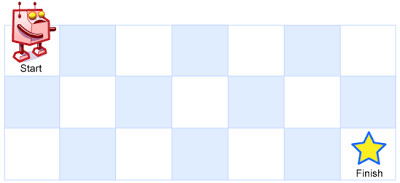
> **输入**：m = 3, n = 7<br>
**输出**：28

In [ ]:
m, n = 3, 7

dp = [[0]*n for _ in range(m)]
dp[0][0] = 1
for ii in range(1, m):
    dp[ii][0] = dp[ii - 1][0]
for jj in range(1, n):
    dp[0][jj] = dp[0][jj - 1]
for ii in range(1, m):
    for jj in range(1, n):
        dp[ii][jj] = dp[ii][jj - 1] + dp[ii - 1][jj]

print(dp[-1][-1])

<span id='P.63'></span>
### [63. 不同路径 II](https://leetcode.cn/problems/unique-paths-ii/)
一个机器人位于一个$m \times n$网格的左上角（起始点在下图中标记为"Start"）。<br>
机器人每次只能向下或者向右移动一步。机器人试图达到网格的右下角（在下图中标记为"Finish"）。<br>
现在考虑网格中有障碍物。那么从左上角到右下角将会有多少条不同的路径？<br>
网格中的障碍物和空位置分别用`1`和`0`来表示。

**示例 1**：
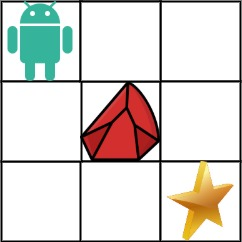
> **输入**：obstacleGrid = [[0,0,0],[0,1,0],[0,0,0]]<br>
**输出**：2<br>
**解释**：3x3 网格的正中间有一个障碍物。
从左上角到右下角一共有 2 条不同的路径：
>1. 向右 $\to$ 向右 $\to$ 向下 $\to$ 向下
>2. 向下 $\to$ 向下 $\to$ 向右 $\to$ 向右

In [ ]:
obstacleGrid = [[0,0,0],[0,1,0],[0,0,0]]
# obstacleGrid = [[0,1],[0,0]]
# obstacleGrid = [[1]]
# obstacleGrid = [[0,0,0,0,0],[0,0,0,0,1],[0,0,0,1,0],[0,0,1,0,0]]
# obstacleGrid = [[0,1,0]]
# obstacleGrid = [[0],[1],[0]]

m, n = len(obstacleGrid), len(obstacleGrid[0])
dp = [[0]*n for _ in range(m)]
if obstacleGrid[0][0] == 0:
    dp[0][0] = 1
for ii in range(1, m):
    if obstacleGrid[ii][0] == 0:
        dp[ii][0] = dp[ii - 1][0]
for jj in range(1, n):
    if obstacleGrid[0][jj] == 0:
        dp[0][jj] = dp[0][jj - 1]
for ii in range(1, m):
    for jj in range(1, n):
        if obstacleGrid[ii][jj] == 0:
            dp[ii][jj] = dp[ii][jj - 1] + dp[ii - 1][jj]

print(dp[-1][-1])

<span id='P.64'></span>
### [64. 最小路径和](https://leetcode.cn/problems/minimum-path-sum/)
$\iff$ <span id='LCR.099'></span>[LCR 099. 最小路径和](https://leetcode.cn/problems/0i0mDW/)  
给定一个包含非负整数的$m \times n$网格`grid`，请找出一条从左上角到右下角的路径，使得路径上的数字总和为最小。<br>
**说明**：每次只能向下或者向右移动一步。

**示例 1**：
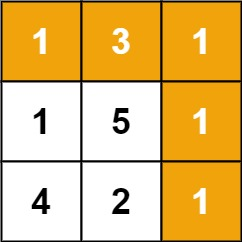
> **输入**：grid = [[1,3,1],[1,5,1],[4,2,1]]<br>
**输出***：7<br>
**解释**：因为路径 1→3→1→1→1 的总和最小。

In [ ]:
grid = [[1,3,1],[1,5,1],[4,2,1]]

m, n = len(grid), len(grid[0])
dp = [[0]*n for _ in range(m)]
dp[0][0] = grid[0][0]
for ii in range(1, m):
    dp[ii][0] = dp[ii - 1][0] + grid[ii][0]
for jj in range(1, n):
    dp[0][jj] = dp[0][jj - 1] + grid[0][jj]
for ii in range(1, m):
    for jj in range(1, n):
        dp[ii][jj] = min(dp[ii][jj - 1], dp[ii - 1][jj]) + grid[ii][jj]

print(dp[-1][-1])

<span id='P.120'></span>
## [120. 三角形最小路径和](https://leetcode.cn/problems/triangle/)
$\iff$ <span id='LCR.100'></span>[LCR 100. 三角形最小路径和](https://leetcode.cn/problems/IlPe0q/)<br>
给定一个三角形`triangle`，找出自顶向下的最小路径和。<br>
每一步只能移动到下一行中相邻的结点上。**相邻的结点**在这里指的是**下标**与**上一层结点下标**相同或者等于**上一层结点下标 + 1**的两个结点。也就是说，如果正位于当前行的下标`i`，那么下一步可以移动到下一行的下标`i`或`i + 1`。

In [ ]:
triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]

dp = [[0]*len(triangle[ii]) for ii in range(len(triangle))]
dp[0][0] = triangle[0][0]
for ii in range(1, len(triangle)):
    for jj in range(len(triangle[ii])):
        if jj == 0:
            dp[ii][0] = dp[ii - 1][jj] + triangle[ii][0]
        elif jj == len(triangle[ii]) - 1:
            dp[ii][-1] = dp[ii - 1][-1] + triangle[ii][-1]
        else:
            dp[ii][jj] = min(dp[ii - 1][jj - 1], dp[ii -1][jj]) + triangle[ii][jj]

print(min(dp[-1]))

<span id='P.118'></span>
### [118. 杨辉三角](https://leetcode.cn/problems/pascals-triangle/)
给定一个非负整数`numRows`，生成「杨辉三角」的前`numRows`行。<br>
在「杨辉三角」中，每个数是它左上方和右上方的数的和。


In [ ]:
numRows = 5

dp = [[0]*(ii + 1) for ii in range(numRows)]
dp[0][0] = 1
for ii in range(1, numRows):
    for jj in range(ii + 1):
        if jj == 0:
            dp[ii][0] = dp[ii - 1][jj]
        elif jj == ii:
            dp[ii][-1] = dp[ii - 1][-1]
        else:
            dp[ii][jj] = dp[ii - 1][jj - 1] + dp[ii -1][jj]

print(dp)

<span id='P.119'></span>
### [119. 杨辉三角 II](https://leetcode.cn/problems/pascals-triangle-ii/)
给定一个非负索引`rowIndex`，返回「杨辉三角」的第`rowIndex`行。<br>
在「杨辉三角」中，每个数是它左上方和右上方的数的和。

## todo
- 221. 最大正方形
- 1162. 地图分析

# 字符串

<span id='P.5'></span>
## [5. 最长回文子串](https://leetcode.cn/problems/longest-palindromic-substring/)
给你一个字符串`s`，找到`s`中最长的回文*子串*。<br>
如果字符串的反序与原始字符串相同，则该字符串称为回文字符串。<br>
*子字符串*是字符串中连续的字符序列。

>题解:   
$P(i,j)$表示字符串$s$的第$i$到$j$个字母组成的串(即$s[i:j]$)是否为回文串:  
$$ dp(i,j) = \begin{cases} \begin{array}{l,l}
true, & 如果子串 S_i \dots S_j 是回文串 \\
false, & otherwise \\
\end{array} \end{cases} $$
状态转移方程: $$P(i,j)=P(i+1,j−1)\ and \ (S_i == S_j)$$  
也就是说, 只有$s[i+1:j−1]$是回文串, 并且$s$的第$i$和$j$个字母相同时, $s[i:j]$才会是回文串。  
边界条件: 
$$ \begin{cases}
P(i,i)=true \\
P(i,i+1)=(S_i == S_j) \\
\end{cases} $$
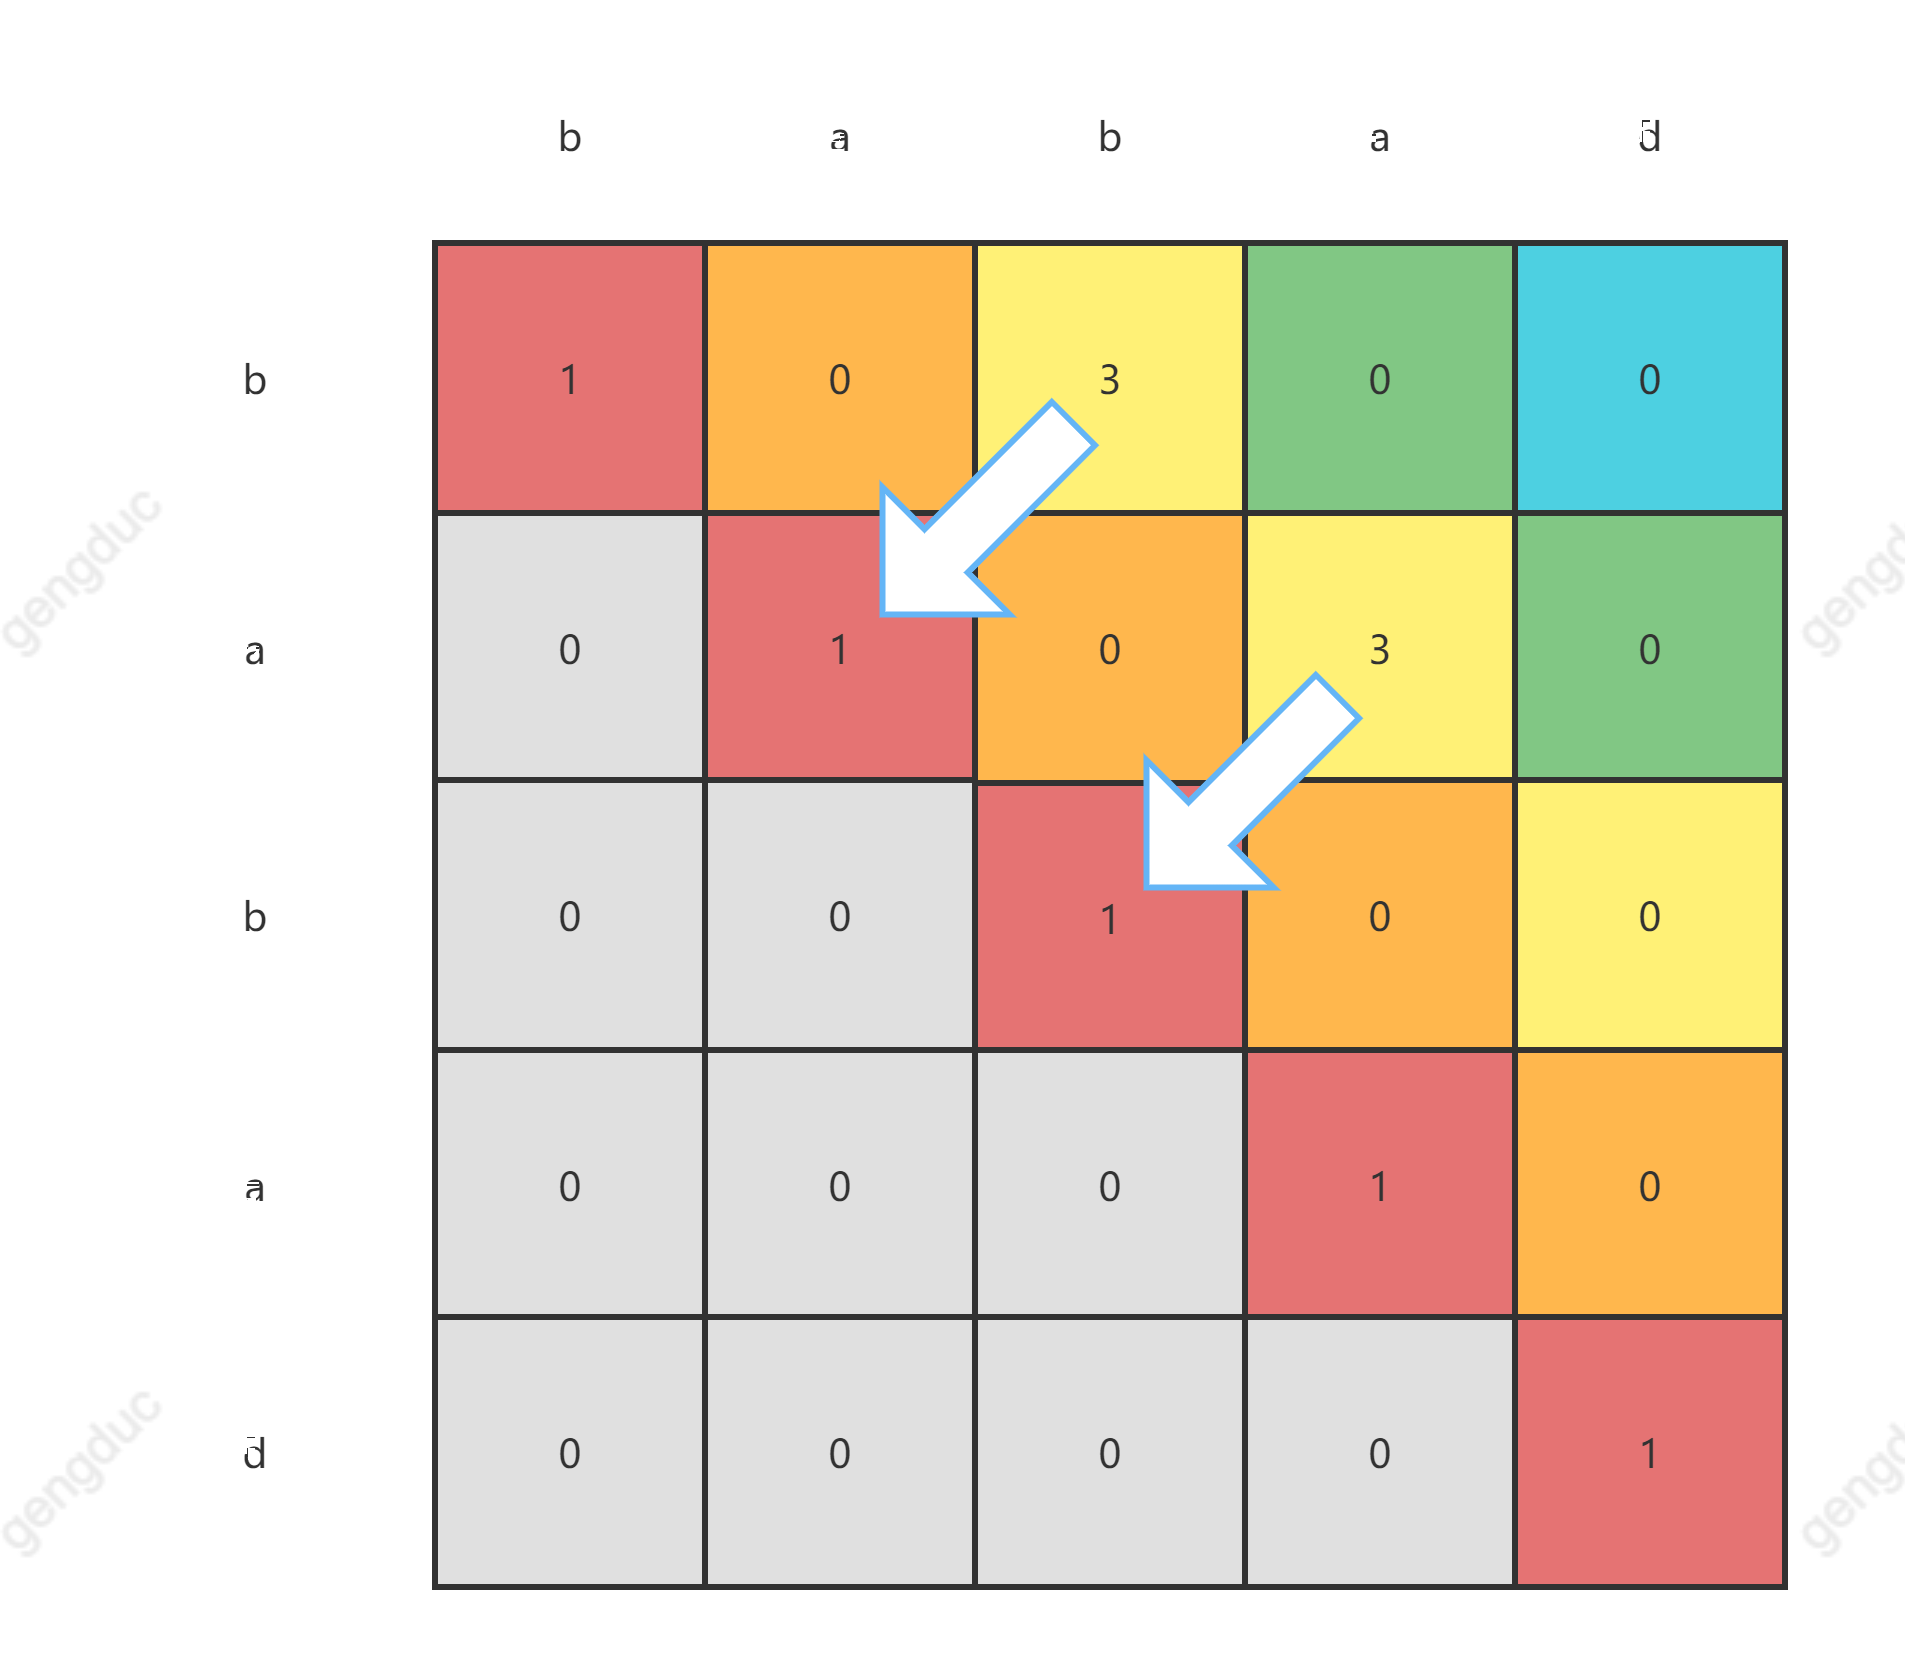

In [ ]:
s = "babad"

output = s[0]
dp = [[False] * len(s) for _ in range(len(s))]
# 主对角线
for ii in range(len(s)):
    dp[ii][ii] = True
# 次对角线
for ii in range(1, len(s)):
    dp[ii - 1][ii] = s[ii - 1] == s[ii]
    if dp[ii - 1][ii]:
        output = s[ii - 1 : ii + 1]
# 剩余对角线
for ii in range(2, len(s)): # length
    for jj in range(ii, len(s)): # index of end
        dp[jj - ii][jj] = s[jj - ii] == s[jj] and dp[jj - ii + 1][jj - 1]
        if dp[jj - ii][jj] == True:
            output = s[jj - ii : jj + 1]

print(output)

In [ ]:
s = "babad"

count = 1
output = s[0]
dp = [[False] * len(s) for _ in range(len(s))]
for ii in range(len(s)):
    dp[ii][ii] = True
for ii in range(len(s) - 2, -1, -1):
    for jj in range(ii + 1, len(s)):
        if s[ii] == s[jj]:
            if ii + 1 <= jj - 1:
                dp[ii][jj] = dp[ii + 1][jj - 1]
            else:
                dp[ii][jj] = True
            if dp[ii][jj] and jj + 1 - ii > count:
                count = jj + 1 - ii
                output = s[ii : jj+1]

print(output)

<span id='P.44'></span>
## [44. 通配符匹配](https://leetcode.cn/problems/wildcard-matching/)
给你一个输入字符串(`s`)和一个字符模式(`p`), 请你实现一个支持`'?'`和`'*'`匹配规则的通配符匹配：
- `'?'`可以匹配任何单个字符。
- `'*'`可以匹配任意字符序列（包括空字符序列）。
判定匹配成功的充要条件是：字符模式必须能够**完全匹配**输入字符串（而不是部分匹配）。

> **题解**:<br>
`dp[i][j]`表示`s`的前`i`个字符与`p`中的前`j`个字符是否能够匹配<br>
状态转移方程如下:
$$ \textit{dp}[i][j] = \begin{cases} 
s_i与p_j相同 \text{ and } \textit{dp}[i-1][j-1], & p_j是小写字母 \\
\textit{dp}[i-1][j-1], & p_j是? \\ 
\textit{dp}[i][j-1] \text{ or } \textit{dp}[i-1][j], & p_j是* 
\end{cases} $$<br>
将前两种转移进行归纳:
$$\textit{dp}[i][j] = \begin{cases} 
\textit{dp}[i-1][j-1], & s_i与p_j相同 \text{ or } p_j是?~(case~1)\\ \textit{dp}[i][j-1] \text{ or } \textit{dp}[i-1][j], & p_j是*~(case~2~or~3)\\ \text{False}, & 其它情况 
\end{cases} $$<br>
例如: 
> - case 1: 如果`s[i]`与`p[j]`匹配成功, 则`dp[i][j]`取决于`dp[i - 1][j - 1]`
$$\begin{matrix}
s & \cdots & \color{Red}{\mathscr{X}} & a \\
& \cdots & i - 1, & i \\
p & \cdots & \color{Red}{\mathscr{X}} & ? \\
& \cdots & j - 1, & j \\
\end{matrix}$$
> - case 2: 如果`p[j] = *`且`*`表示0个字符, 则`dp[i][j]`取决于`dp[i][j - 1]`
$$\begin{matrix}
s & \cdots &  & \color{Red}{a} \\
& \cdots &  & i \\
p & \cdots & \color{Red}{\mathscr{X}} & * \\
& \cdots & j - 1, & j \\
\end{matrix}$$
> - case 3: 如果`p[j] = *`且`*`表示`s`的最后一个字符(即是`s[i]`), 则`dp[i][j]`取决于`dp[i - 1][j]`
$$\begin{matrix}
s & \cdots & \color{Red}{\mathscr{X}} & a \\
& \cdots & i - 1, & i \\
p & \cdots & & \color{Red}{*} \\
& \cdots & & j \\
\end{matrix}$$

In [ ]:
def isMatch(s, p):
    if len(s) == 0 and len(p) == 0:
        return True
    elif len(s) > 0 and len(p) == 0:
        return False
    elif len(s) == 0 and len(p) > 0:
        for char in p:
            if char != '*':
                return False
        return True

    dp = [[False] * len(p) for _ in range(len(s))]
    if s[0] == p[0] or p[0] == '?' or p[0] == '*':
        dp[0][0] = True
    
    # 第一行
    for j in range(1, len(p)):
        if p[j] == '*':
            dp[0][j] = dp[0][j - 1]
        else:
            if s[0] == p[j] or p[j] == '?': # 如果 s[0] 与 p 的最后一个字符(即 p[j])匹配成功, 则需要 p[j] 之前的元素全为 '*', p[0][j]才为 True
                label = True
                for k in range(j):
                    if p[k] != '*':
                        label = False
                dp[0][j] = label
    
    # 第一列
    for i in range(1, len(s)):
        if p[0] == '*': # 如果 p[0] = '*', 因为 '*' 可以表示任务字符, 因此第一列全为 True
            dp[i][0] = True
    
    for i in range(1, len(s)):
        for j in range(1, len(p)):
            if s[i] == p[j] or p[j] == '?':
                dp[i][j] = dp[i - 1][j - 1] # case 1
            elif p[j] == '*':
                dp[i][j] = (dp[i][j - 1]    # case 2
                         or dp[i - 1][j])   # case 3
    
    # 输出
    string = "  :  "
    for char in p:
        string += char + "      "
    print(string)
    for i in range(len(dp)):
        print(s[i], ":", dp[i])
    return dp[-1][-1]

isMatch("adceb", "*a*b")

<span id='P.10'></span>
### [10. 正则表达式匹配](https://leetcode.cn/problems/regular-expression-matching/)
$\iff$ <span id='LCR.137'></span> [LCR 137. 模糊搜索验证](https://leetcode.cn/problems/zheng-ze-biao-da-shi-pi-pei-lcof/)<br>
给你一个字符串`s`和一个字符规律`p`, 请你来实现一个支持`'.'`和`'*'`的正则表达式匹配。
- `'.'`匹配任意单个字符
- `'*'`匹配零个或多个**前面的那一个元素**

所谓匹配, 是要涵盖**整个**字符串`s`的，而不是部分字符串。

> **题解**:
`dp[i][j]`表示`s`的前`i`个字符与`p`中的前`j`个字符是否能够匹配<br>
状态转移方程如下：
$$ dp[i][j] = \begin{cases}
\text{if }(p[j] \neq *) = \begin{cases}
dp[i - 1][j - 1], & s_i与p_j相同 \text{ or } p_j是.~(case~1)\\
\text{false}, & \text{otherwise} \end{cases} \\
\text{if }(p[j] = *) = \begin{cases}
dp[i][j - 2] \text{ or } dp[i - 1][j], & s_i与p_{j-1}相同 \text{ or } p_{j-1}是.~(case~2~or~3) \\
dp[i][j - 2], & \text{otherwise}~(case~4) \end{cases}
\end{cases} $$<br>
例如: 
> - case 1: 如果`p[j] != *`且`s[i]`与`p[j]`匹配成功, 则`dp[i][j]`取决于`dp[i - 1][j - 1]`
$$\begin{matrix}
s & \cdots & \color{Red}{\mathscr{X}} & a \\
& \cdots & i - 1, & i \\
p & \cdots & \color{Red}{\mathscr{X}} & . \\
& \cdots & j - 1, & j \\
\end{matrix}$$
> - case 2: 如果`p[j] = *`且`s[i]`与`p[j-1]`匹配*成功*且`a*`表示0个字符,`dp[i][j]`取决于`dp[i][j - 2]`
$$\begin{matrix}
s & \cdots & & & \color{Red}{a} \\
& \cdots & & & i \\
p & \cdots & \color{Red}{\mathscr{X}} & a & * \\
& \cdots & j - 2, & j - 1, & j \\
\end{matrix}$$
> - case 3: 如果`p[j] = *`且`s[i]`与`p[j-1]`匹配*成功*且`a*`表示`s`的最后一个字符(即是`s[i]`), 则`dp[i][j]`取决于`dp[i - 1][j]`
$$\begin{matrix}
s & \cdots & & \color{Red}{a} & a \\
& \cdots & & i-1, & i \\
p & \cdots & & a & \color{Red}{*} \\
& \cdots & & j - 1, & j \\
\end{matrix}$$
> - case 4: 如果`p[j] = *`且`s[i]`与`p[j-1]`匹配*失败*且`b*`表示0个字符,`dp[i][j]`取决于`dp[i][j - 2]`
$$\begin{matrix}
s & \cdots & & & \color{Red}{a} \\
& \cdots & & & i \\
p & \cdots & \color{Red}{\mathscr{X}} & b & * \\
& \cdots & j - 2, & j - 1, & j \\
\end{matrix}$$
[动画演示](https://leetcode.cn/problems/regular-expression-matching/solutions/2361807/10-zheng-ze-biao-da-shi-pi-pei-dong-tai-m5z1i/)

In [ ]:
s = "aab"
p = "c*a*b"

dp = [[False] * (len(p) + 1) for _ in range(len(s) + 1)]
dp[0][0] = True
for i in range(0, len(s) + 1):
    for j in range(1, len(p) + 1):
        if p[j - 1] != '*':
            if i - 1 >= 0 and (s[i - 1] == p[j - 1] or p[j - 1] == '.'):
                dp[i][j] = dp[i - 1][j - 1]   # case 1
        else:
            if j - 2 >= 0:
                if i - 1 >= 0 and (s[i - 1] == p[j - 2] or p[j - 2] == '.'):
                    dp[i][j] = (dp[i][j - 2]  # case 2
                             or dp[i - 1][j]) # case 3
                else:
                    dp[i][j] = dp[i][j - 2]   # case 4

# 输出
string = "  : 0      "
for char in p:
    string += char + "      "
print(string)
for i in range(len(dp)):
    if i == 0:
        print(0, ":", dp[i])
    else:
        print(s[i - 1], ":", dp[i])
print(dp[-1][-1])

## [97. 交错字符串](https://leetcode.cn/problems/interleaving-string/)
<=> [剑指 Offer II 096. 字符串交织](https://leetcode.cn/problems/IY6buf/)

todo: https://leetcode.cn/problems/interleaving-string/solution/dong-tai-gui-hua-zhu-xing-jie-shi-python3-by-zhu-3/

给定三个字符串 s1、s2、s3，请判断 s3 能不能由 s1 和 s2 交织（交错） 组成。

两个字符串 s 和 t 交织 的定义与过程如下，其中每个字符串都会被分割成若干 非空 子字符串：

- s = s1 + s2 + ... + sn
- t = t1 + t2 + ... + tm
- |n - m| <= 1
- 交织 是 s1 + t1 + s2 + t2 + s3 + t3 + ... 或者 t1 + s1 + t2 + s2 + t3 + s3 + ...

提示：a + b 意味着字符串 a 和 b 连接。

>题解：  
$dp(i,j)$表示$s_1$的前$i$个元素和$s_2$的前$j$个元素是否能交织组成$s_3$的前$i + j$个元素。  
a)如果$s_1$的第$i$个元素和$s_3$的第$i + j$个元素相等，那么$s_1$的前$i$个元素和$s_2$的前$j$个元素是否能交织组成$s_3$的前$i + j$个元素  
取决于$s_1$的前$i - 1$个元素和$s_2$的前$j$个元素是否能交织组成$s_3$的前$i + j - 1$个元素，  
即$dp(i, j)$取决于$dp(i - 1, j)$，在此情况下<font color="red">如果$dp(i - 1, j)$为真，则$dp(i, j)$也为真。</font> Why?  
b)如果$s_2$的第$j$个元素和$s_3$的第$i + j$个元素相等并且$dp(i, j - 1)$为真，则$dp(i, j)$也为真。  
动态规划转移方程: $$dp(i,j)=[dp(i−1,j)\ and\ s_1(i−1)=s_3(i + j - 1)]\ or\ [dp(i,j−1)\ and\ s_2(j−1)=s_3(i + j - 1)]$$
边界条件: $$dp(0,0) = True$$

In [ ]:
s1 = "aabcc"
s2 = "dbbca"
s3 = "aadbbcbcac"

if len(s1) + len(s2) == len(s3):
    dp = [[False]*(len(s2)+1) for _ in range(len(s1)+1)]
    dp[0][0] = True
    for ii in range(1,len(s1)+1):
        dp[ii][0] = s1[0:ii] == s3[0:ii]
    for jj in range(1,len(s2)+1):
        dp[0][jj] = s2[0:jj] == s3[0:jj]
    for ii in range(1,len(s1)+1):
        for jj in range(1,len(s2)+1):
            dp[ii][jj] = (dp[ii-1][jj] and s1[ii-1] == s3[ii+jj-1]) or (dp[ii][jj-1] and s2[jj-1] == s3[ii+jj-1])
    print(dp[-1][-1])
else:
    print(False)

## todo: [583. 两个字符串的删除操作](https://leetcode-cn.com/problems/delete-operation-for-two-strings/)

$dp[i][j]$ 表示 $word_1[0:i]$ 和 $word_2[0:j]$ 的最长公共子序列的长度  
$word_1[0:i]$ 表示 $word_1$ 长度为 $i$ 的前缀，$word_2[0:j]$ 表示 $word_2$ 长度为 $j$ 的前缀
$ dp[i][j] = \begin{cases} dp[i-1][j-1]+1, & word_1[i] = word_2[j] \\ max( dp[i-1][j], dp[i][j-1] ), & word_1[i] \neq word_2[j]\end{cases}$

example:  
$word_1$ = "park", $word_2$ = "spake"  
$ \begin{matrix}dp & & 0 & & 1 & & 2 & & 3 & & 4\\ & & s & & p & & a & & k & & a\\ 0 & p & 0 & & 1 & & 1 & & 1 & & 1 \\ & & & & \downarrow & \searrow & & & \downarrow & & \downarrow \\ 1 & a & 0 & \rightarrow & 1 & & 2 & \rightarrow & 2 & \rightarrow & 2 \\ & & & & \downarrow & & \downarrow & & \downarrow & & \downarrow \\ 2 & r & 0 & \rightarrow & 1 & \rightarrow & 2 & \rightarrow & 2 & \rightarrow & 2 \\ & & & & \downarrow & & \downarrow & \searrow & & & \downarrow \\ 3 & k & 0 & \rightarrow & 1 & \rightarrow & 2 & & 3 & \rightarrow & 3 \end{matrix} $

第1列表示 $word_1[0:i]$ 与 $word_2[0]$ 的最长公共子序列的长度,最大值为1  
第1行表示 $word_2[0:j]$ 与 $word_1[0]$ 的最长公共子序列的长度,最大值为1

In [ ]:
# 583.两个字符串的删除操作 python
# word1 = "sea"
# word2 = "eat"
word1 = "park"
word2 = "spake"


dp = [[0]*len(word2) for _ in range(len(word1))]
if word1[0] == word2[0]:
    dp[0][0] = 1
for ii in range(1,len(word1)):
    if word1[ii] == word2[0]:
        dp[ii][0] = max(dp[ii-1][0],1)
    else:
        dp[ii][0] = dp[ii-1][0]
for jj in range(1,len(word2)):
    if word2[jj] == word1[0]:
        dp[0][jj] = max(dp[0][jj-1],1)
    else:
        dp[0][jj] = dp[0][jj-1]
for ii in range(1,len(word1)):
    for jj in range(1,len(word2)):
        if word1[ii] == word2[jj]:
            dp[ii][jj] = dp[ii-1][jj-1]+1
        else:
            dp[ii][jj] = max(dp[ii][jj-1],dp[ii-1][jj])

print(len(word1)+len(word2)-2*dp[-1][-1])

In [ ]:
// 583.两个字符串的删除操作 cpp

#include <iostream>
#include <vector>
#include <string>
using namespace std;

string word1 = "park";
string word2 = "spake";

vector<vector<int>> dp;
for (size_t ii = 0; ii < word1.size(); ii++)
{
    vector<int> temp;
    for (size_t jj = 0; jj < word2.size(); jj++)
    {
        temp.emplace_back(0);
    }
    dp.emplace_back(temp);
}
if (word1[0] == word2[0])
{
    dp[0][0] = 1;
}
for (size_t ii = 1; ii < word1.size(); ii++)
{
    if (word1[ii] == word2[0])
    {
        dp[ii][0] = 1;
    }
    else
    {
        dp[ii][0] = dp[ii - 1][0];
    }
}
for (size_t jj = 1; jj < word2.size(); jj++)
{
    if (word2[jj] == word1[0])
    {
        dp[0][jj] = 1;
    }
    else
    {
        dp[0][jj] = dp[0][jj - 1];
    }
}
for (size_t ii = 1; ii < word1.size(); ii++)
{
    for (size_t jj = 1; jj < word2.size(); jj++)
    {
        if (word1[ii] == word2[jj])
        {
            dp[ii][jj] = dp[ii - 1][jj - 1] + 1;
        }
        else
        {
            dp[ii][jj] = max(dp[ii - 1][jj], dp[ii][jj - 1]);
        }
    }
}

cout << word1.size() + word2.size() - 2*dp[word1.size() - 1][word2.size() - 1] << endl;

## todo: [1143. 最长公共子序列](https://leetcode-cn.com/problems/longest-common-subsequence/)

In [ ]:
# 1143.最长公共子序列 python
text1 = "park"
text2 = "spake" 

dp = [[0]*len(text2) for _ in range(len(text1))]
if text1[0] == text2[0]:
    dp[0][0] = 1
for ii in range(1,len(text1)):
    if text1[ii] == text2[0]:
        dp[ii][0] = 1
    else:
        dp[ii][0] = dp[ii-1][0]
for jj in range(1,len(text2)):
    if text2[jj] == text1[0]:
        dp[0][jj] = 1
    else:
        dp[0][jj] = dp[0][jj-1]
for ii in range(1,len(text1)):
    for jj in range(1,len(text2)):
        if text1[ii] == text2[jj]:
            dp[ii][jj] = dp[ii-1][jj-1]+1
        else:
            dp[ii][jj] = max(dp[ii][jj-1],dp[ii-1][jj])

print(dp[-1][-1])

In [ ]:
// 1143.最长公共子序列 cpp
#include <iostream>
#include <vector>
#include <string>
using namespace std;

string text1 = "park";
string text2 = "spake";

vector<vector<int>> dp;
for (size_t ii = 0; ii < text1.size(); ii++)
{
    vector<int> temp;
    for (size_t jj = 0; jj < text2.size(); jj++)
    {
        temp.emplace_back(0);
    }
    dp.emplace_back(temp);
}
if (text1[0] == text2[0])
{
    dp[0][0] = 1;
}
for (size_t ii = 1; ii < text1.size(); ii++)
{
    if (text1[ii] == text2[0])
    {
        dp[ii][0] = 1;
    }
    else
    {
        dp[ii][0] = dp[ii - 1][0];
    }
}
for (size_t jj = 1; jj < text2.size(); jj++)
{
    if (text2[jj] == text1[0])
    {
        dp[0][jj] = 1;
    }
    else
    {
        dp[0][jj] = dp[0][jj-1];
    }
}
for (size_t ii = 1; ii < text1.size(); ii++)
{
    for (size_t jj = 1; jj < text2.size(); jj++)
    {
        if (text1[ii] == text2[jj])
        {
            dp[ii][jj] = dp[ii - 1][jj - 1] + 1;
        }
        else
        {
            dp[ii][jj] = max(dp[ii - 1][jj], dp[ii][jj - 1]);
        }
    }
}

cout << dp[text1.size() - 1][text2.size() - 1] << endl;

## [72. 编辑距离]
## [115. 不同的子序列]
## [583. 两个字符串的删除操作]